In [2]:
# ===========================================
# 📦 1. Libraries
# ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LassoLarsCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

SEED = 42
np.random.seed(SEED)


# ===========================================
# 📂 2. Load Data
# ===========================================
train = pd.read_csv("train.csv", parse_dates=['Date'])
test  = pd.read_csv("test.csv", parse_dates=['Date'])
store = pd.read_csv("store.csv")

# Merge store info
train = train.merge(store, how='left', on='Store')
test  = test.merge(store, how='left', on='Store')

print("Train shape:", train.shape)
print("Test shape:", test.shape)


# ===========================================
# 🧹 3. Basic Preprocessing
# ===========================================
train = train[(train['Open'] == 1) & (train['Sales'] > 0)]

if 'CompetitionDistance' in train.columns:
    max_dist = train['CompetitionDistance'].max()
    train['CompetitionDistance'] = train['CompetitionDistance'].fillna(max_dist*1.5)
    test['CompetitionDistance']  = test['CompetitionDistance'].fillna(max_dist*1.5)

if 'Promo2' in train.columns:
    train['Promo2'] = train['Promo2'].fillna(0).astype(int)
    test['Promo2']  = test['Promo2'].fillna(0).astype(int)

train['StateHoliday'] = train['StateHoliday'].astype(str)
test['StateHoliday']  = test['StateHoliday'].astype(str)


# ===========================================
# 🧠 4. Feature Engineering
# ===========================================
for df in [train, test]:
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# Sort for lag computation
train = train.sort_values(['Store', 'Date'])

# Lag features (7, 14, 28 days)
for lag in [7, 14, 28]:
    train[f'Sales_lag_{lag}'] = train.groupby('Store')['Sales'].shift(lag)

# Rolling mean and std
train['rolling_mean_7'] = train.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
train['rolling_std_7']  = train.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).std())

# Drop rows with NA after lag/rolling
train = train.dropna().reset_index(drop=True)
# ===========================================
# 🔧 Create Lag Features for Test Set
# ===========================================
# Combine train and test temporarily to create lag features
# We'll use the last known sales from train to compute test lags

# First, ensure test has the same temporal features
# (already done above in the feature engineering loop)

# For test set, we need to use the most recent train data
# Create a mapping of Store -> recent sales for lag computation
for lag in [7, 14, 28]:
    # For each store, get the last 'lag' days of sales from train
    store_last_sales = train.groupby('Store')['Sales'].tail(lag).reset_index()
    
    # For simplicity, use the mean of last 'lag' days as the lag feature
    # (A more sophisticated approach would align by actual dates)
    store_lag_mean = train.groupby('Store')['Sales'].tail(lag).groupby(
        train.groupby('Store').tail(lag)['Store']
    ).mean().to_dict()
    
    test[f'Sales_lag_{lag}'] = test['Store'].map(store_lag_mean)

# Rolling features for test
store_rolling_mean = train.groupby('Store')['Sales'].tail(7).groupby(
    train.groupby('Store').tail(7)['Store']
).mean().to_dict()

store_rolling_std = train.groupby('Store')['Sales'].tail(7).groupby(
    train.groupby('Store').tail(7)['Store']
).std().to_dict()

test['rolling_mean_7'] = test['Store'].map(store_rolling_mean)
test['rolling_std_7'] = test['Store'].map(store_rolling_std)

# Fill any remaining NaNs with 0 or median
test[['Sales_lag_7', 'Sales_lag_14', 'Sales_lag_28', 'rolling_mean_7', 'rolling_std_7']] = \
    test[['Sales_lag_7', 'Sales_lag_14', 'Sales_lag_28', 'rolling_mean_7', 'rolling_std_7']].fillna(0)


# ===========================================
# ✂️ 5. Train/Validation Split
# ===========================================
cutoff_date = train['Date'].max() - pd.Timedelta(weeks=6)
train_df = train[train['Date'] <= cutoff_date]
valid_df = train[train['Date'] > cutoff_date]

y_train = train_df['Sales']
X_train = train_df.drop(['Sales','Customers','Date'], axis=1)

y_valid = valid_df['Sales']
X_valid = valid_df.drop(['Sales','Customers','Date'], axis=1)

X_test  = test.drop(['Id','Date'], axis=1)


# ===========================================
# ⚙️ 6. Preprocessing Pipeline
# ===========================================
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])


# ===========================================
# 📏 7. Evaluation Metrics
# ===========================================
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return (np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask]))*100)

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def adjusted_r2(y_true, y_pred, X):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X.shape[1]
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate(y_true, y_pred, X=None):
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }
    if X is not None:
        metrics['Adj_R2'] = adjusted_r2(y_true, y_pred, X)
    return metrics


# ===========================================
# 🤖 8. Model Training & Evaluation
# ===========================================
results = []

# Linear Regression
pipe_lr = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_valid)
results.append({'Model':'Linear Regression', **evaluate(y_valid, pred_lr, X_valid)})

# Lasso LARS
pipe_lars = Pipeline([('pre', preprocessor), ('model', LassoLarsCV(cv=3))])
pipe_lars.fit(X_train, y_train)
pred_lars = pipe_lars.predict(X_valid)
results.append({'Model':'Lasso LARS', **evaluate(y_valid, pred_lars, X_valid)})

# Decision Tree
pipe_dt = Pipeline([('pre', preprocessor), ('model', DecisionTreeRegressor(random_state=SEED, max_depth=15))])
pipe_dt.fit(X_train, y_train)
pred_dt = pipe_dt.predict(X_valid)
results.append({'Model':'Decision Tree', **evaluate(y_valid, pred_dt, X_valid)})

# Random Forest
pipe_rf = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1))])
pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_valid)
results.append({'Model':'Random Forest', **evaluate(y_valid, pred_rf, X_valid)})

# KNN
pipe_knn = Pipeline([('pre', preprocessor), ('model', KNeighborsRegressor(n_neighbors=5))])
pipe_knn.fit(X_train, y_train)
pred_knn = pipe_knn.predict(X_valid)
results.append({'Model':'KNN', **evaluate(y_valid, pred_knn, X_valid)})

# SVR (subset for speed)
pipe_svr = Pipeline([('pre', preprocessor), ('model', SVR(kernel='rbf', C=1.0, gamma='scale'))])
subset_idx = np.random.choice(len(X_train), size=20000, replace=False)
pipe_svr.fit(X_train.iloc[subset_idx], y_train.iloc[subset_idx])
pred_svr = pipe_svr.predict(X_valid)
results.append({'Model':'SVR', **evaluate(y_valid, pred_svr, X_valid)})

# Compare Results
score_df = pd.DataFrame(results).sort_values("MAE")
print("\nModel Performance Summary:")
print(score_df)


# ===========================================
# 🏆 9. Final Model & Submission
# ===========================================
best_model = pipe_rf  # you can manually choose based on score_df
y_full = train['Sales']
X_full = train.drop(['Sales','Customers','Date'], axis=1)
best_model.fit(X_full, y_full)

# Predict on test
test_preds = best_model.predict(X_test)
submission = pd.DataFrame({'Id': test['Id'], 'Sales': test_preds})
submission.to_csv("submission.csv", index=False)

print("\n✅ Submission file created: submission.csv")


Train shape: (1017209, 18)
Test shape: (41088, 17)

Model Performance Summary:
               Model          MAE         RMSE       MAPE        R2    Adj_R2
3      Random Forest   665.131582   986.169426  10.402840  0.863770  0.863479
4                KNN   761.234769  1112.169833  11.813986  0.826734  0.826364
2      Decision Tree   809.202257  1222.698463  12.520542  0.790584  0.790137
0  Linear Regression  1129.558490  1590.603885  18.022033  0.645599  0.644843
1         Lasso LARS  1136.827883  1598.464523  18.227901  0.642088  0.641324
5                SVR  1720.230778  2418.137421  29.197165  0.180909  0.179160

✅ Submission file created: submission.csv


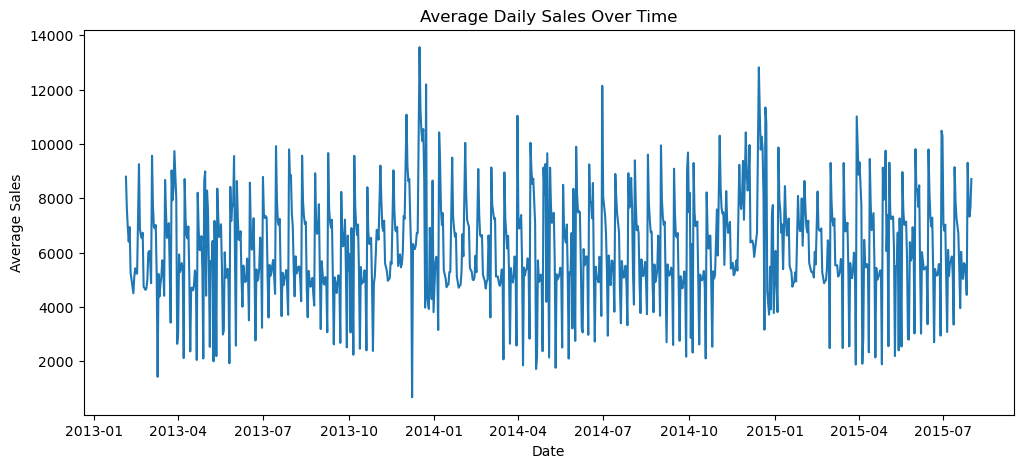

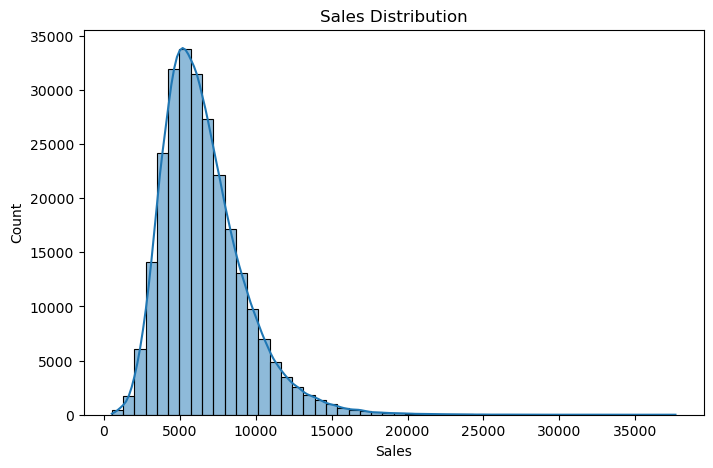

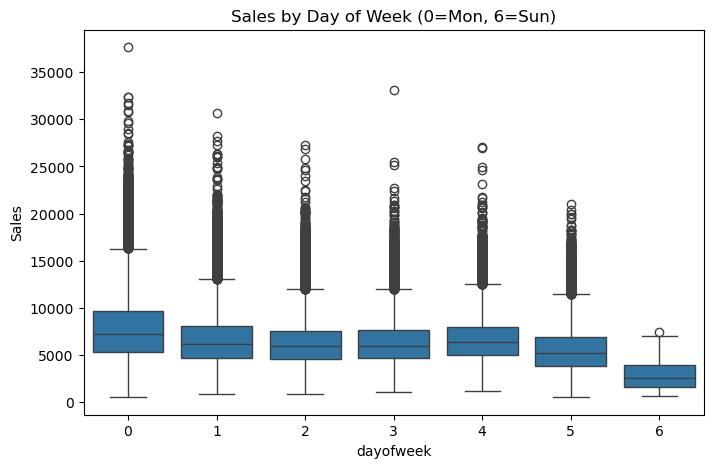

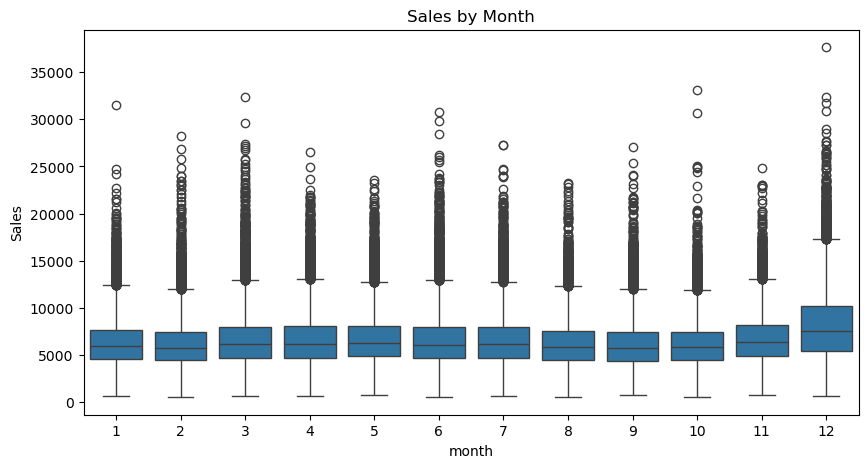

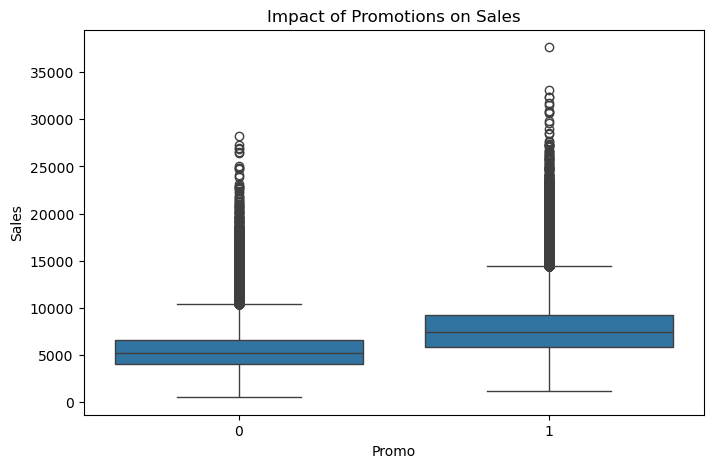

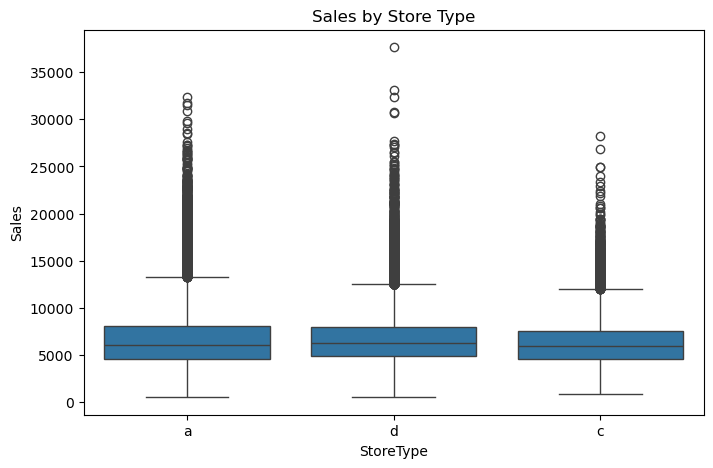

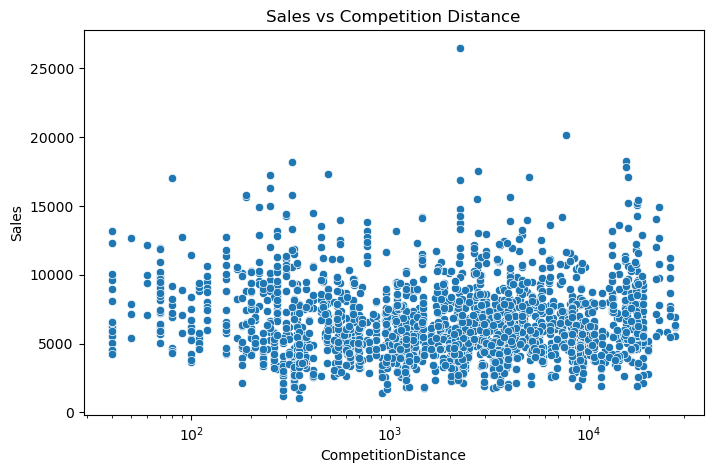

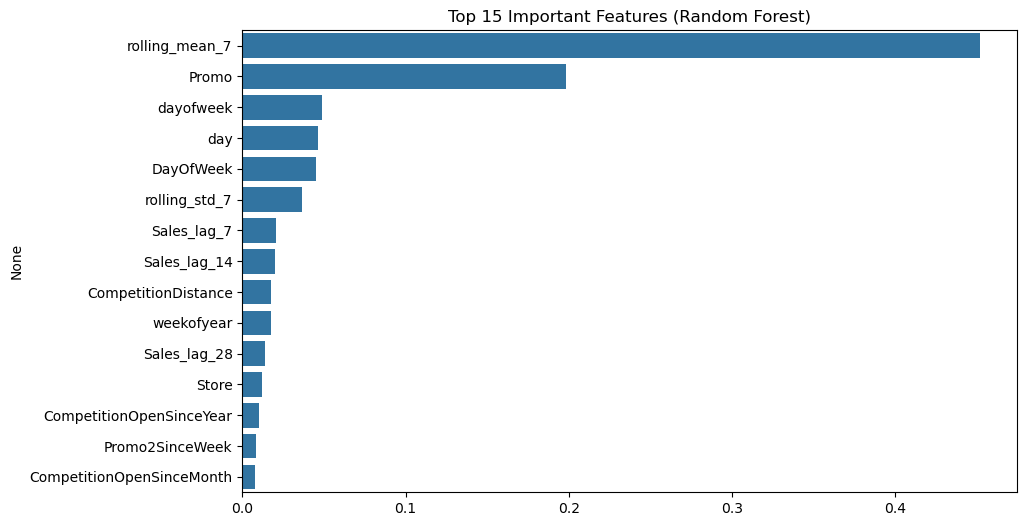

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Overall Sales Trend
plt.figure(figsize=(12,5))
sns.lineplot(data=train.groupby("Date")["Sales"].mean())
plt.title("Average Daily Sales Over Time")
plt.ylabel("Average Sales")
plt.xlabel("Date")
plt.show()

# 2. Sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(train["Sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

# 3. Sales by Day of Week
plt.figure(figsize=(8,5))
sns.boxplot(x="dayofweek", y="Sales", data=train)
plt.title("Sales by Day of Week (0=Mon, 6=Sun)")
plt.show()

# 4. Sales by Month (Seasonality)
plt.figure(figsize=(10,5))
sns.boxplot(x="month", y="Sales", data=train)
plt.title("Sales by Month")
plt.show()

# 5. Effect of Promotions
plt.figure(figsize=(8,5))
sns.boxplot(x="Promo", y="Sales", data=train)
plt.title("Impact of Promotions on Sales")
plt.show()

# 6. Sales by Store Type
if "StoreType" in train.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="StoreType", y="Sales", data=train)
    plt.title("Sales by Store Type")
    plt.show()

# 7. Sales vs Competition Distance
if "CompetitionDistance" in train.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x="CompetitionDistance", y="Sales", data=train.sample(2000, random_state=42))
    plt.title("Sales vs Competition Distance")
    plt.xscale("log")
    plt.show()

# 8. Feature Importance (Random Forest)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
X_feat = X_train.copy()
rf.fit(pd.get_dummies(X_feat), y_train)

feat_importances = pd.Series(rf.feature_importances_, index=pd.get_dummies(X_feat).columns)
top_features = feat_importances.sort_values(ascending=False)[:15]

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Important Features (Random Forest)")
plt.show()

In [7]:
from scipy import stats


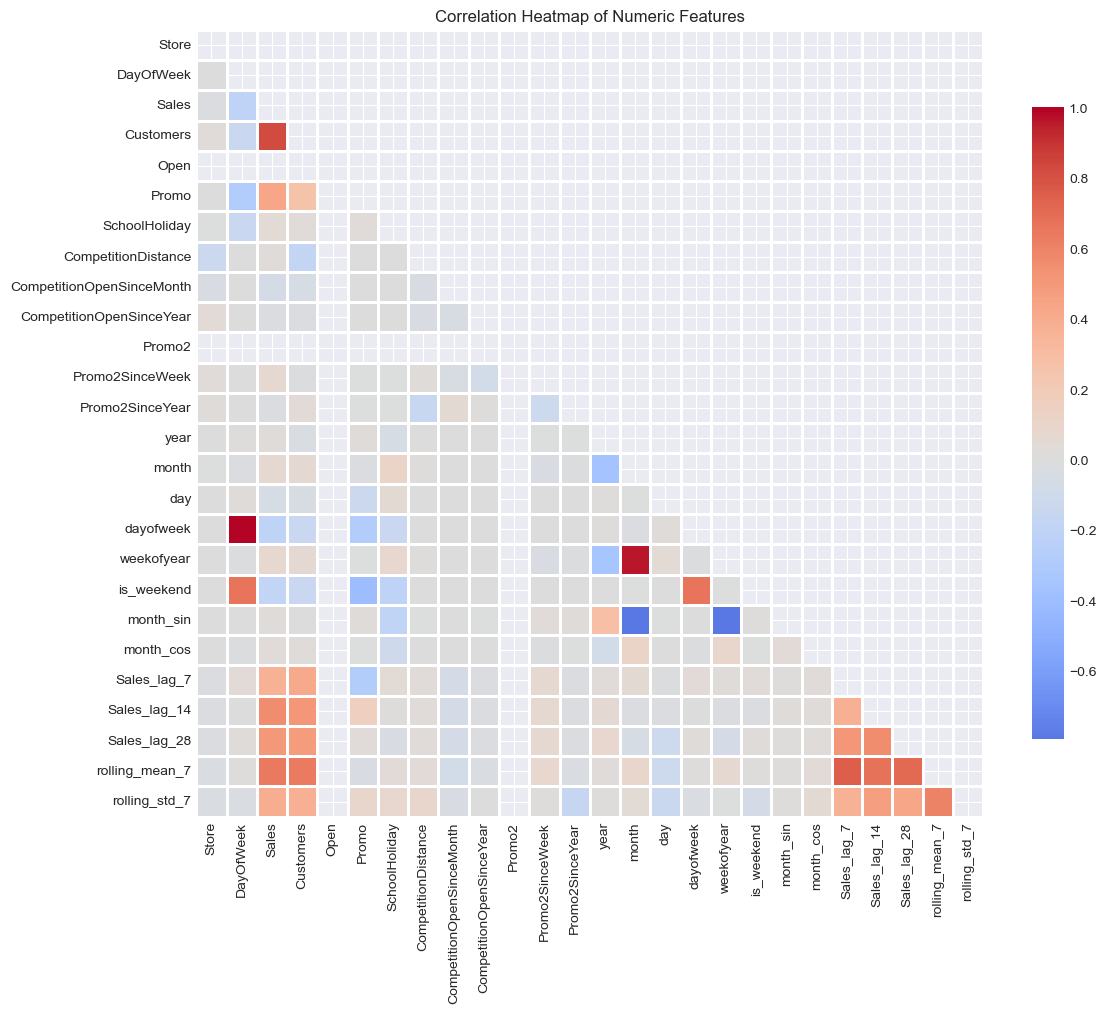

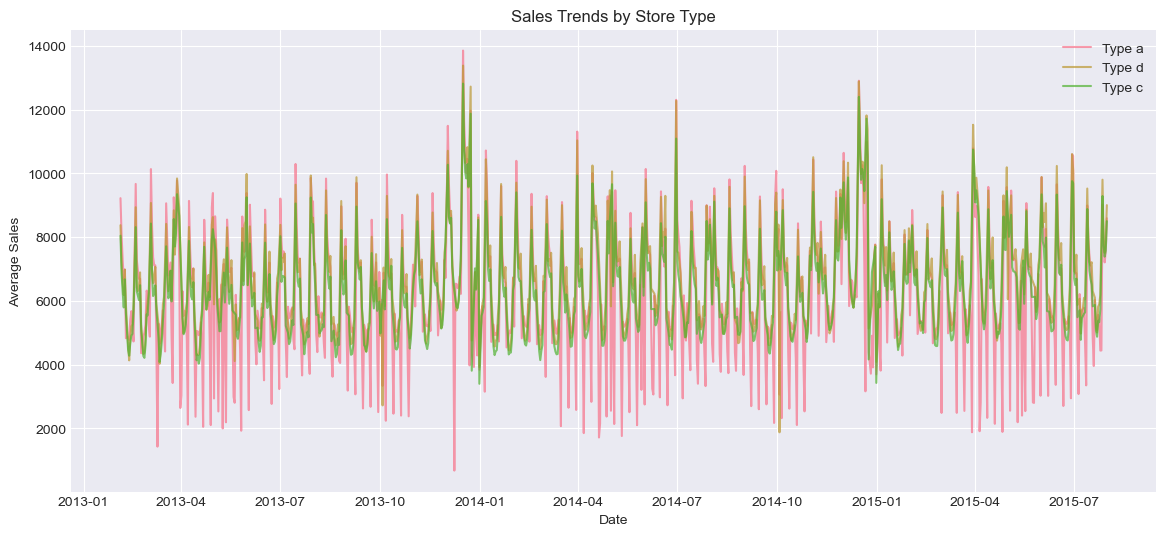

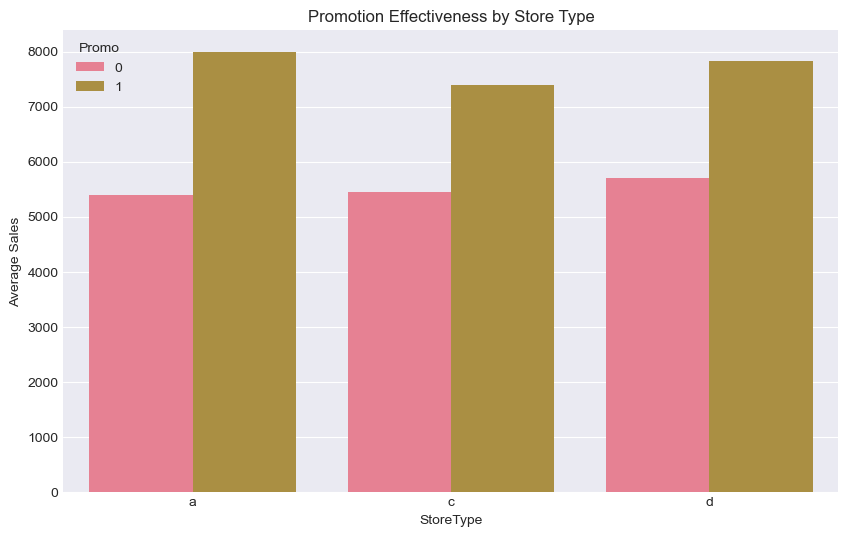

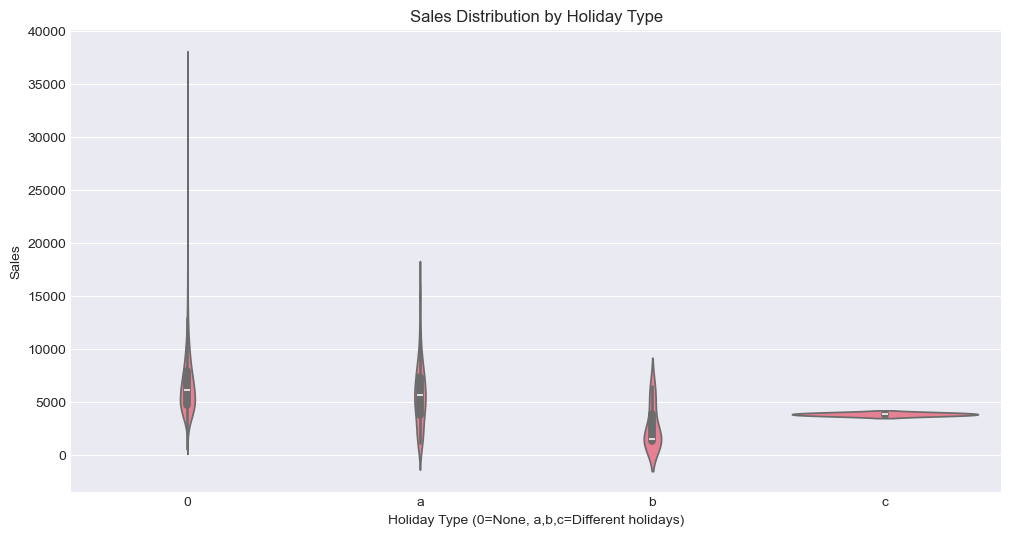

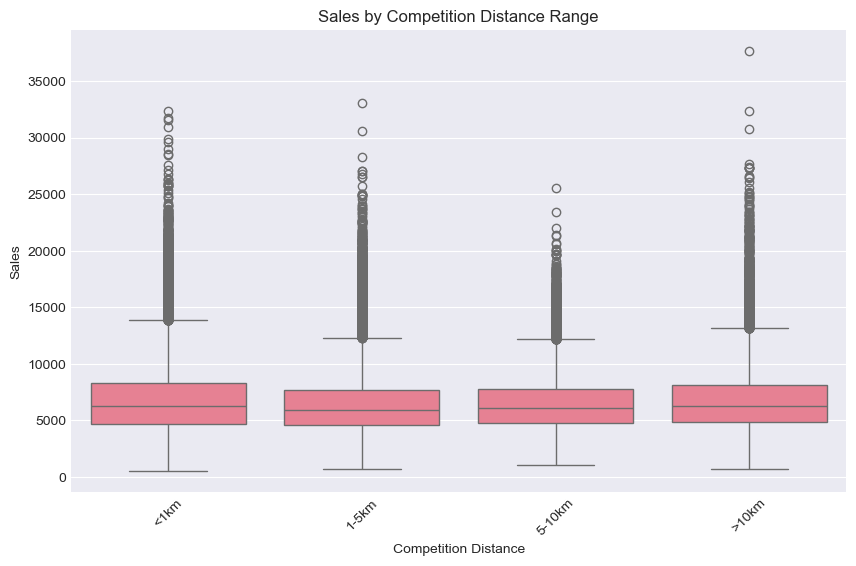

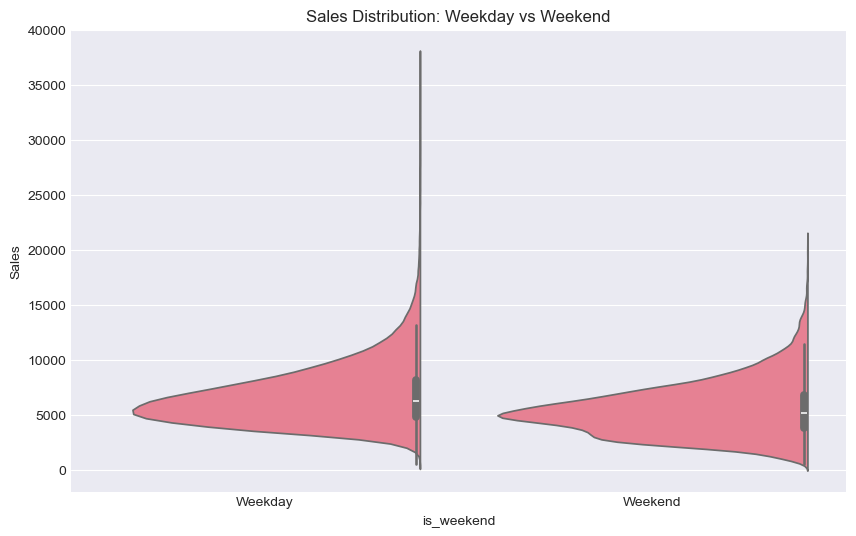

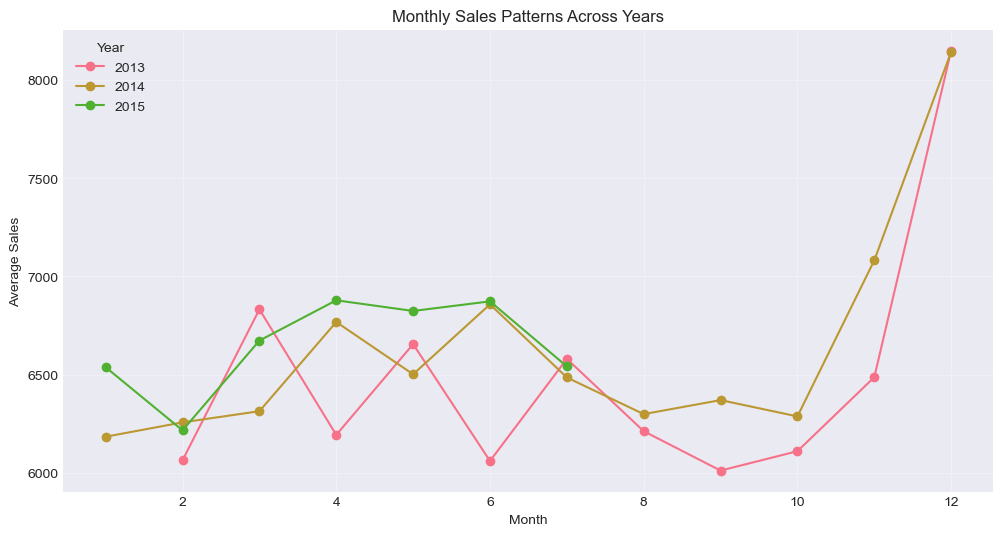

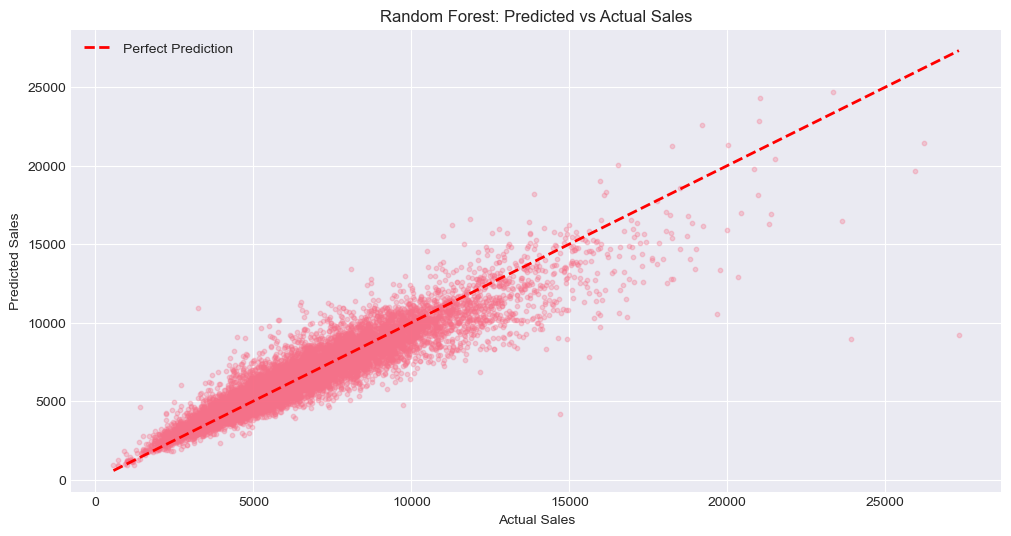

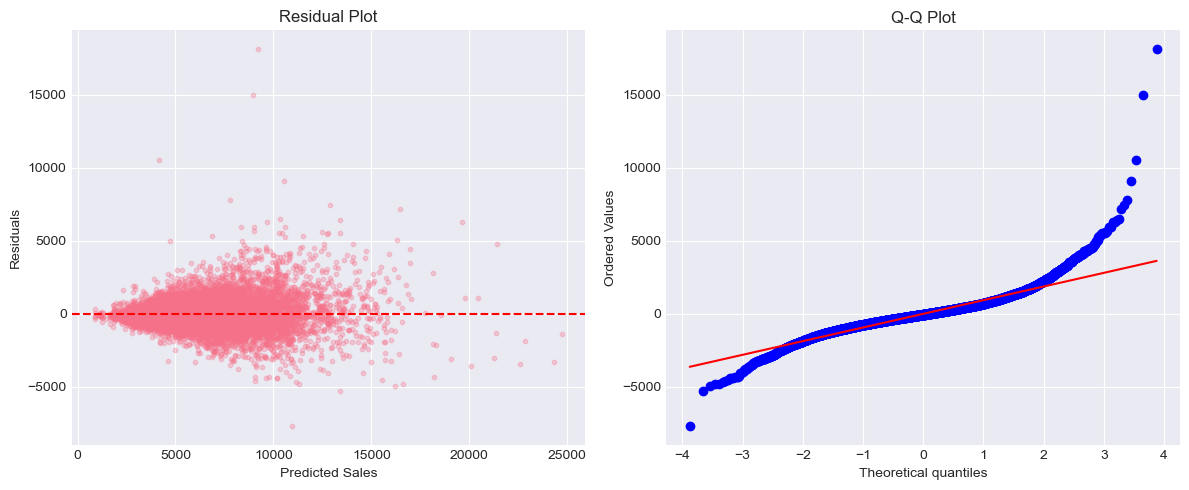

<Figure size 1200x600 with 0 Axes>

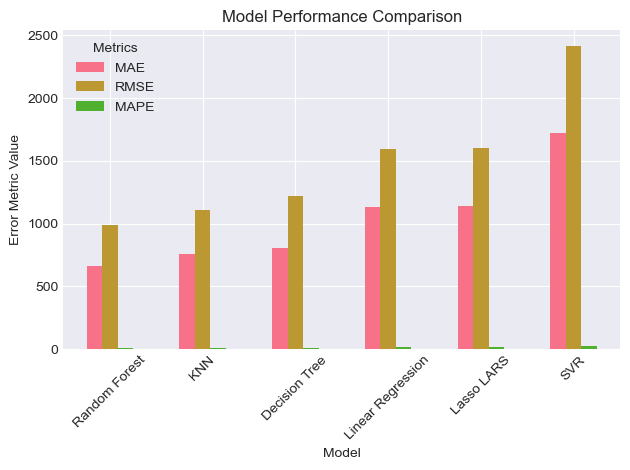

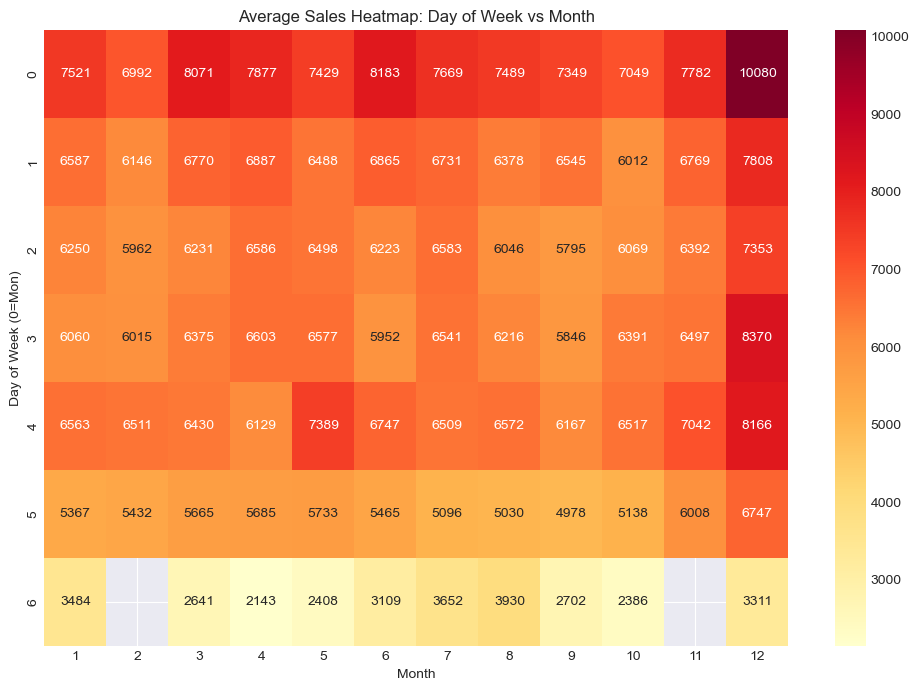

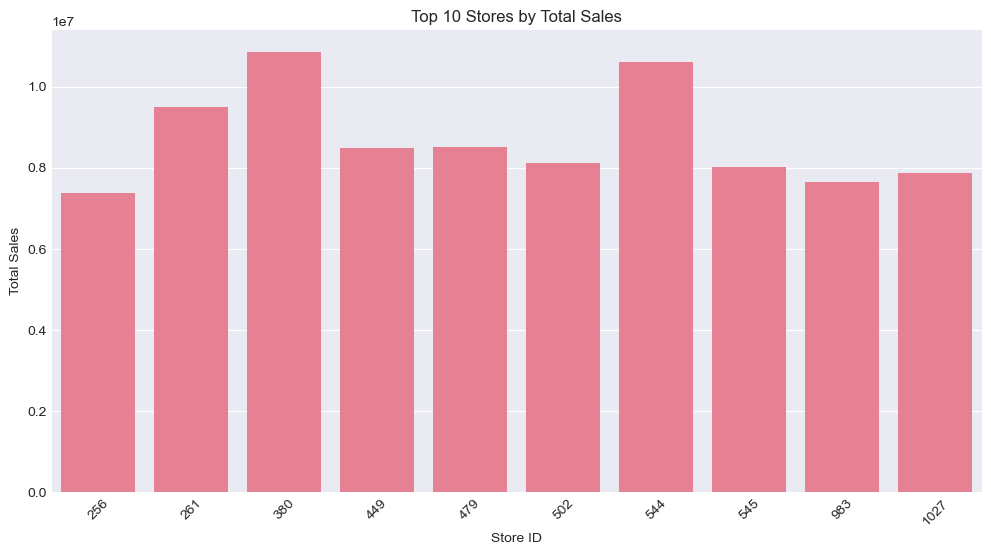

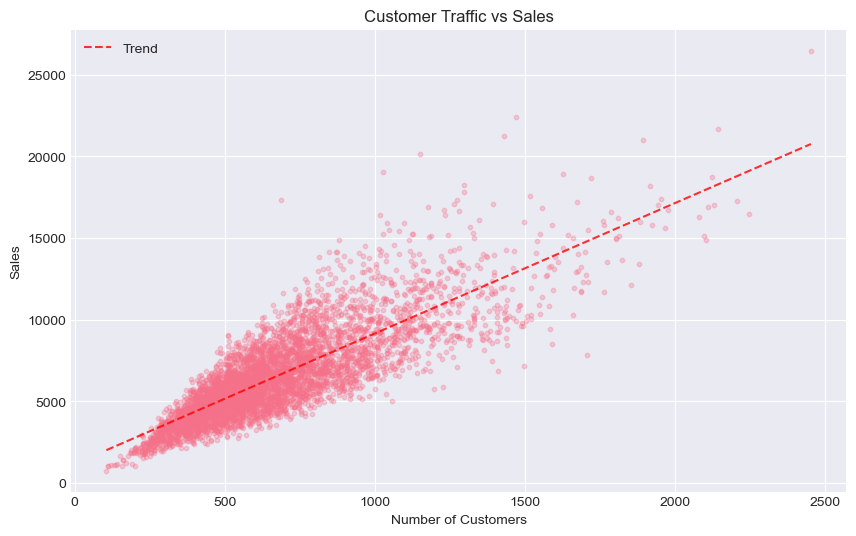

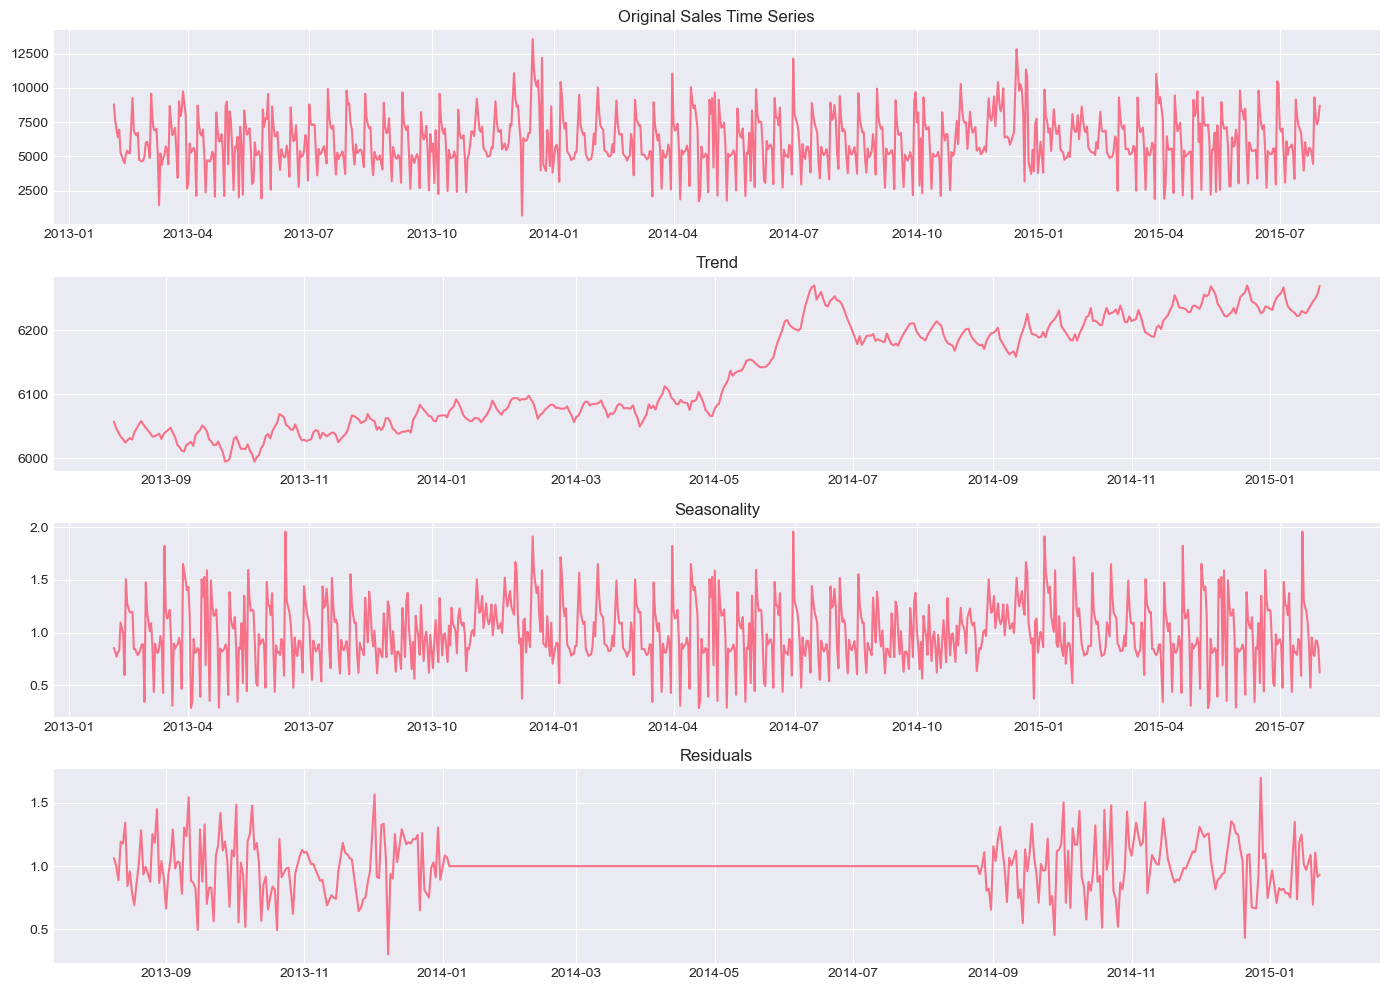

In [9]:
# Set style
sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

# 9. Correlation Heatmap
plt.figure(figsize=(12,10))
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

# 10. Sales Trends by Store Type Over Time
if 'StoreType' in train.columns:
    plt.figure(figsize=(14,6))
    for store_type in train['StoreType'].unique():
        data = train[train['StoreType']==store_type].groupby('Date')['Sales'].mean()
        plt.plot(data.index, data.values, label=f'Type {store_type}', alpha=0.7)
    plt.title('Sales Trends by Store Type')
    plt.xlabel('Date')
    plt.ylabel('Average Sales')
    plt.legend()
    plt.show()

# 11. Promo Effectiveness by Store Type
if 'StoreType' in train.columns:
    plt.figure(figsize=(10,6))
    promo_effect = train.groupby(['StoreType', 'Promo'])['Sales'].mean().reset_index()
    sns.barplot(data=promo_effect, x='StoreType', y='Sales', hue='Promo')
    plt.title('Promotion Effectiveness by Store Type')
    plt.ylabel('Average Sales')
    plt.show()

# 12. Sales Distribution by Holiday Type
plt.figure(figsize=(12,6))
sns.violinplot(data=train, x='StateHoliday', y='Sales')
plt.title('Sales Distribution by Holiday Type')
plt.ylabel('Sales')
plt.xlabel('Holiday Type (0=None, a,b,c=Different holidays)')
plt.show()

# 13. Competition Distance vs Sales (Binned)
if 'CompetitionDistance' in train.columns:
    train['CompDist_Bin'] = pd.cut(train['CompetitionDistance'], 
                                    bins=[0, 1000, 5000, 10000, 50000], 
                                    labels=['<1km', '1-5km', '5-10km', '>10km'])
    plt.figure(figsize=(10,6))
    sns.boxplot(data=train, x='CompDist_Bin', y='Sales')
    plt.title('Sales by Competition Distance Range')
    plt.ylabel('Sales')
    plt.xlabel('Competition Distance')
    plt.xticks(rotation=45)
    plt.show()

# 14. Sales Pattern: Weekday vs Weekend
plt.figure(figsize=(10,6))
sns.violinplot(data=train, x='is_weekend', y='Sales', split=True)
plt.title('Sales Distribution: Weekday vs Weekend')
plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.show()

# 15. Yearly Sales Comparison
plt.figure(figsize=(12,6))
yearly_sales = train.groupby(['year', 'month'])['Sales'].mean().reset_index()
for year in yearly_sales['year'].unique():
    year_data = yearly_sales[yearly_sales['year']==year]
    plt.plot(year_data['month'], year_data['Sales'], marker='o', label=str(year))
plt.title('Monthly Sales Patterns Across Years')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.show()

# 16. Model Predictions vs Actual (Validation Set)
plt.figure(figsize=(12,6))
plt.scatter(y_valid, pred_rf, alpha=0.3, s=10)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Random Forest: Predicted vs Actual Sales')
plt.legend()
plt.show()

# 17. Residual Plot
residuals = y_valid - pred_rf
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(pred_rf, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

# 18. Model Performance Comparison
plt.figure(figsize=(12,6))
metrics_to_plot = ['MAE', 'RMSE', 'MAPE']
score_df_plot = score_df.set_index('Model')[metrics_to_plot]
score_df_plot.plot(kind='bar', rot=45)
plt.title('Model Performance Comparison')
plt.ylabel('Error Metric Value')
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

# 19. Sales Heatmap by Day and Month
plt.figure(figsize=(12,8))
pivot_table = train.pivot_table(values='Sales', index='dayofweek', 
                                 columns='month', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Average Sales Heatmap: Day of Week vs Month')
plt.ylabel('Day of Week (0=Mon)')
plt.xlabel('Month')
plt.show()

# 20. Top 10 Stores by Sales
plt.figure(figsize=(12,6))
top_stores = train.groupby('Store')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_stores.index, y=top_stores.values)
plt.title('Top 10 Stores by Total Sales')
plt.xlabel('Store ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

# 21. Customer Traffic vs Sales
if 'Customers' in train.columns:
    plt.figure(figsize=(10,6))
    sample_data = train.sample(5000, random_state=42)
    plt.scatter(sample_data['Customers'], sample_data['Sales'], alpha=0.3, s=10)
    plt.xlabel('Number of Customers')
    plt.ylabel('Sales')
    plt.title('Customer Traffic vs Sales')
    
    # Add trend line
    z = np.polyfit(sample_data['Customers'], sample_data['Sales'], 1)
    p = np.poly1d(z)
    plt.plot(sample_data['Customers'].sort_values(), 
             p(sample_data['Customers'].sort_values()), 
             "r--", alpha=0.8, label='Trend')
    plt.legend()
    plt.show()

# 22. Sales Decomposition (Trend, Seasonality)
from statsmodels.tsa.seasonal import seasonal_decompose

daily_sales = train.groupby('Date')['Sales'].mean()
plt.figure(figsize=(14,10))
decomposition = seasonal_decompose(daily_sales, model='multiplicative', period=365)

plt.subplot(411)
plt.plot(daily_sales)
plt.title('Original Sales Time Series')
plt.subplot(412)
plt.plot(decomposition.trend)
plt.title('Trend')
plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.title('Seasonality')
plt.subplot(414)
plt.plot(decomposition.resid)
plt.title('Residuals')
plt.tight_layout()
plt.show()
